In [53]:
#Part 1: In this part, we are importing libraries required to create a project in Qiskit.

import sys
import numpy as np
import matplotlib.pyplot as plt

import qiskit
try: 
    import qiskit_aer
except Exception:
    qiskit_aer = None

print("python:", sys.version.splitlines()[0])
print("qiskit:", getattr(qiskit, "__version__", None))   #to print out the versions of qiskit and qiskit_aer
print("qiskit_aer:", getattr(qiskit_aer, "__version__", None))


python: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
qiskit: 2.2.1
qiskit_aer: 0.17.2


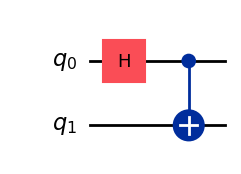

In [59]:
#Part 2: In this part we are creating a circuit. It is a circuit of 2-qubit Bell state

from qiskit import QuantumCircuit   
#building a circuit with H on qubit 0
qc = QuantumCircuit(2)
qc.h(0)        # Hadamard on qubit 0
qc.cx(0, 1)    # Controlled-NOT with control=0, target=1

# Drawing using mpl
qc.draw(output="mpl")   #to draw the circuit

In [57]:
#Part 3: In this part, we are defining two two-qubit Pauli operators of ZZ, ZI, IZ, XX, XI, IX. 

from qiskit.quantum_info import Pauli

ZZ = Pauli('ZZ')   #correlation of Z on both qubits
ZI = Pauli('ZI')   #Z on qubit 0, I on quibit 1
IZ = Pauli('IZ')   #I on q0, Z on q1
XX = Pauli('XX')   #correlation of X on both qubits
XI = Pauli('XI')   #X on q0, I on q1
IX = Pauli('IX')   #I on q0, X on q1

observables = [ZZ, ZI, IZ, XX, XI, IX]

In [61]:
#Part 4 & 5: Using Qiskit Aer Estimator to compute the expectation values for each Bell state
from qiskit_aer.primitives import Estimator 

estimator = Estimator()   # Using Qiskit Aer Estimator to simulate expectation values locally

job = estimator.run([qc] * len(observables), observables)

job.result()   #shows expectation values for observables on bell states == 1.,  0.015625 ,  0.015625 ,  1., -0.0078125, -0.0078125

EstimatorResult(values=array([ 1.        ,  0.02148438,  0.02148438,  1.        , -0.03320312,
       -0.03320312]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0053386, 'sample_measure_time': 0.0020691, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 15591, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 6, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9995384216308594, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0053386, 'sample_measure_time': 0.00206

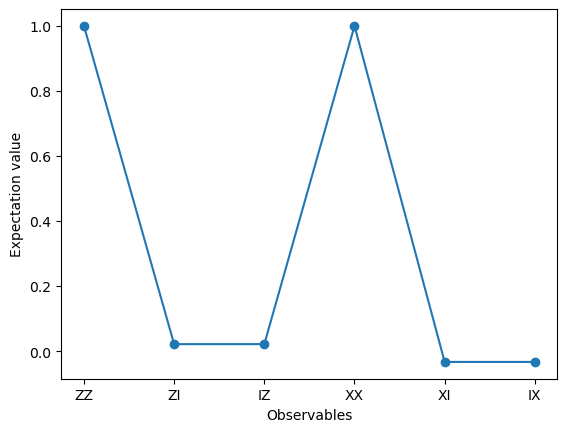

In [67]:
#Part 6:In this part, we imported matplotlib to create a graph to visualize the states
import matplotlib.pyplot as plt

data = ['ZZ', 'ZI', 'IZ', 'XX', 'XI', 'IX']   #setting the data in array
values = job.result().values

plt.plot(data, values, '-o')    #plotting the graph
plt.xlabel('Observables')
plt.ylabel('Expectation value')
plt.show()

In [65]:
#Part 7 has been completed within each part